# Breast Cancer Gene Expression Analysis

This project analyzes **gene expression data** collected from **breast cancer patients and healthy individuals** to identify the specific genes whose activity levels consistently differ between the two groups. Using statistical tests and dimensionality reduction, the project highlights **gene patterns that may serve as breast cancer indicators**, helping separate patients and healthy individuals based on their gene expression profiles.

## About the Dataset

The dataset was taken from the **Gene Expression Omnibus (GEO)** and contains microarray gene expression data from 29 breast tissue samples. The **29 columns** represent each **patient** and **~54000 rows** represent **gene probes** that measure expression levels. The patients were marked either **"Normal", "Normal Risk Atypia", "High Risk", "High Risk Atypia"**. For simplicity, the former two have been labeled as **"Healthy"** while the latter two have been labeled as **"Cancer"** to allow clearer comparison.

For a more detailed explanation, the webpage can be visited here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi. The **GEO Accession ID** is **GSE153796**.

## Project Workflow

**Data Preparation &rarr; Statistical Analysis &rarr; Dimensionality Reduction**  

1. **Data Preparation**
   - Transposed the dataset so **each row represents a patient**, and **each column represents a gene probe**.
   - Assigned each patient a label: "Healthy" or "Cancer".
2. **Statistical Analysis (T-test)**
   - Ran t-tests on each gene to find which ones showed significant difference in expression levels between cancer and hhealthy patients.
   - Selected the genes with **p-values < 0.01** as the most significant.  
3. **Dimensionality Reduction (PCA)**
   - Applied **Principal Component Analysis** on the significant genes to reduce the dataset into 2 columns (i.e. dimensions) for 2D plotting.
   - Visualized patients on a scatter plot, showing **clear grouping** by health status (cancer vs. healthy). 

## Results

- Out of ~54000 gene probes, **156 genes** showed strong statistical significance **(p < 0.01)** between cancer and healthy patients.
- PCA visualization using these genes showed **mostly clear separation** between the two patient groups, with some overlap:
  - Healthy and cancer patients generally clustered in distinct regions on the 2D plot.
  - This suggests that **gene expression patterns from a relatively small number of genes can help distinguish cancer risk**.

## Conclusion

This project demonstrates how statistical testing and dimensionality reduction can revveal **key differences in gene expression between breast cancer and healthy patients**.
- A subset of **156 genes** showed strong potential as breast cancer indicators.
- Visual analysis confirmed that these gene expression patterns can help separate the two groupds.
The results highlight how even without machine leaerning models, basic statistical tools and clear visualizations can uncover valuable biological insights.

## Code Implementation

### Data Preparation

#### Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

#### Data Loading

In [3]:
dataset_path = "C:/Users/Acer/Desktop/Projects for Data Science/Cancer Biomarkers/GSE153796_series_matrix.txt/GSE153796_series_matrix.txt"

with open(dataset_path, 'rt') as f:
    lines = f.readlines()

data_start_index = 0
for i, line in enumerate(lines):
    if line.startswith('!series_matrix_table_begin'):
        data_start_index = i + 1 # Data table starts *after* this line
        break

header_lines = lines[:data_start_index]
data_lines = lines[data_start_index:-1]

df = pd.read_csv(io.StringIO("".join(data_lines)), sep='\t', index_col=0)
df

,GSM4654222,GSM4654223,GSM4654224,GSM4654225,GSM4654226,GSM4654227,GSM4654228,GSM4654229,GSM4654230,GSM4654231,...,GSM4654241,GSM4654242,GSM4654243,GSM4654244,GSM4654245,GSM4654246,GSM4654247,GSM4654248,GSM4654249,GSM4654250
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,238.54500,4142.77000,381.50800,1841.92000,2077.25000,705.84400,2326.15000,4318.54000,403.83900,4395.84000,...,341.06700,606.2970,2670.61000,565.97800,3780.45000,331.22300,1010.44000,1254.83000,511.54200,1180.84000
1053_at,440.02800,17.75140,88.52450,182.50700,348.12700,478.51500,124.56500,833.89400,231.01500,89.16420,...,10.35540,163.9440,21.92230,159.10400,142.01600,87.86170,242.60300,514.81600,139.92100,145.10000
117_at,557.68700,47.01350,242.26700,21.66380,115.19400,364.26200,87.77950,168.78400,328.44500,111.39400,...,826.39200,41.4675,36.04470,433.34000,41.93840,496.10500,537.62100,233.19000,330.18400,81.28760
121_at,97.79310,277.82000,84.00780,247.61200,19.77670,250.20000,113.26300,47.79670,76.54660,54.45970,...,83.17780,14.2209,100.31800,50.16640,60.72740,50.72890,48.57150,125.03000,84.16730,20.82730
1255_g_at,4.80885,4.50582,3.64088,6.98241,6.75245,4.99706,3.08273,6.97407,6.74915,2.21168,...,2.55223,21.5025,16.35440,14.11210,2.08343,3.24626,8.76993,6.64910,3.16692,3.25862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-ThrX-5_at,782.78200,4826.85000,958.51300,1210.69000,2575.00000,225.79000,166.79900,1808.71000,231.50000,4533.41000,...,2396.25000,46.3622,162.20400,201.22700,244.27100,77.02600,138.69200,611.97400,372.29300,935.10400
AFFX-ThrX-M_at,815.73200,5988.67000,1931.19000,1413.99000,2306.52000,292.97600,197.94700,1990.66000,321.77900,4662.69000,...,3693.78000,158.4370,180.38700,268.65200,477.28500,104.71400,423.63400,807.27200,381.66900,1303.17000
AFFX-TrpnX-3_at,4.75925,18.19590,1.81168,2.68477,13.34780,8.82138,1.56345,1.08955,6.19483,4.70956,...,6.66550,19.6956,1.37915,2.39707,4.88206,3.54732,4.57331,4.47437,1.08798,18.02750


#### Initial Data Exploration

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

#### Data Preparation

In [6]:
# Transposing the dataset so that each row is a patient and each column is a probe
df_transposed = df.T
df_transposed

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM4654222,238.545,440.0280,557.6870,97.7931,4.808850,780.115,123.4790,45.56280,3969.530,46.71230,...,65307.3,54094.80,99792.2,84032.7,5503.590,782.7820,815.732,4.759250,3.67787,32.47070
GSM4654223,4142.770,17.7514,47.0135,277.8200,4.505820,414.465,43.9169,27.66780,2331.990,3.73430,...,74105.4,60939.60,113337.0,95779.0,28804.300,4826.8500,5988.670,18.195900,6.11384,3.05005
GSM4654224,381.508,88.5245,242.2670,84.0078,3.640880,286.897,26.7931,37.09810,2037.470,9.09136,...,19057.1,15716.50,28608.3,23175.9,4871.130,958.5130,1931.190,1.811680,10.87570,4.51907
GSM4654225,1841.920,182.5070,21.6638,247.6120,6.982410,105.093,74.4618,28.74280,588.991,16.02080,...,26014.3,21686.00,40458.2,32676.3,9638.770,1210.6900,1413.990,2.684770,17.19690,8.37567
GSM4654226,2077.250,348.1270,115.1940,19.7767,6.752450,798.524,110.5740,14.67210,2911.350,63.31530,...,26479.9,21995.10,41317.7,34227.3,11000.300,2575.0000,2306.520,13.347800,11.92780,9.90608
GSM4654227,705.844,478.5150,364.2620,250.2000,4.997060,288.489,26.9342,47.13880,2171.680,15.47280,...,17349.6,13814.80,26681.3,21047.3,2059.340,225.7900,292.976,8.821380,3.04112,12.60900
GSM4654228,2326.150,124.5650,87.7795,113.2630,3.082730,177.678,40.6946,53.46050,1159.290,25.87000,...,10684.4,8497.44,15888.9,12908.6,850.965,166.7990,197.947,1.563450,1.71780,11.70220
GSM4654229,4318.540,833.8940,168.7840,47.7967,6.974070,606.824,92.6619,8.25513,969.275,2.60650,...,26986.1,22198.80,43625.9,34756.8,6819.540,1808.7100,1990.660,1.089550,6.10945,4.32374
GSM4654230,403.839,231.0150,328.4450,76.5466,6.749150,378.963,122.5610,38.66670,4342.040,35.37990,...,42688.3,34678.60,66292.9,51912.7,2569.190,231.5000,321.779,6.194830,9.52906,15.63380
GSM4654231,4395.840,89.1642,111.3940,54.4597,2.211680,173.364,39.0522,30.89780,1390.360,11.98110,...,35689.3,28948.90,52718.7,43296.9,15600.900,4533.4100,4662.690,4.709560,2.64436,9.75963


In [8]:
# Labelling patients as healthy vs. cancerous
patient_labels = {'GSM4654222':"Healthy",
'GSM4654223':"Healthy",
'GSM4654224':"Healthy",
'GSM4654225':"Healthy",
'GSM4654226':"Healthy",
'GSM4654227':"Healthy",
'GSM4654228':"Cancer",
'GSM4654229':"Cancer",
'GSM4654230':"Cancer",
'GSM4654231':"Cancer",
'GSM4654232':"Cancer",
'GSM4654233':"Cancer",
'GSM4654234':"Cancer",
'GSM4654235':"Cancer",
'GSM4654236':"Cancer",
'GSM4654237':"Healthy",
'GSM4654238':"Healthy",
'GSM4654239':"Healthy",
'GSM4654240':"Healthy",
'GSM4654241':"Cancer",
'GSM4654242':"Healthy",
'GSM4654243':"Cancer",
'GSM4654244':"Cancer",
'GSM4654245':"Cancer",
'GSM4654246':"Healthy",
'GSM4654247':"Healthy",
'GSM4654248':"Healthy",
'GSM4654249':"Healthy",
'GSM4654250':"Healthy"}

df_transposed['Label'] = df_transposed.index.map(patient_labels)
df_transposed

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,Label
GSM4654222,238.545,440.0280,557.6870,97.7931,4.808850,780.115,123.4790,45.56280,3969.530,46.71230,...,54094.80,99792.2,84032.7,5503.590,782.7820,815.732,4.759250,3.67787,32.47070,Healthy
GSM4654223,4142.770,17.7514,47.0135,277.8200,4.505820,414.465,43.9169,27.66780,2331.990,3.73430,...,60939.60,113337.0,95779.0,28804.300,4826.8500,5988.670,18.195900,6.11384,3.05005,Healthy
GSM4654224,381.508,88.5245,242.2670,84.0078,3.640880,286.897,26.7931,37.09810,2037.470,9.09136,...,15716.50,28608.3,23175.9,4871.130,958.5130,1931.190,1.811680,10.87570,4.51907,Healthy
GSM4654225,1841.920,182.5070,21.6638,247.6120,6.982410,105.093,74.4618,28.74280,588.991,16.02080,...,21686.00,40458.2,32676.3,9638.770,1210.6900,1413.990,2.684770,17.19690,8.37567,Healthy
GSM4654226,2077.250,348.1270,115.1940,19.7767,6.752450,798.524,110.5740,14.67210,2911.350,63.31530,...,21995.10,41317.7,34227.3,11000.300,2575.0000,2306.520,13.347800,11.92780,9.90608,Healthy
GSM4654227,705.844,478.5150,364.2620,250.2000,4.997060,288.489,26.9342,47.13880,2171.680,15.47280,...,13814.80,26681.3,21047.3,2059.340,225.7900,292.976,8.821380,3.04112,12.60900,Healthy
GSM4654228,2326.150,124.5650,87.7795,113.2630,3.082730,177.678,40.6946,53.46050,1159.290,25.87000,...,8497.44,15888.9,12908.6,850.965,166.7990,197.947,1.563450,1.71780,11.70220,Cancer
GSM4654229,4318.540,833.8940,168.7840,47.7967,6.974070,606.824,92.6619,8.25513,969.275,2.60650,...,22198.80,43625.9,34756.8,6819.540,1808.7100,1990.660,1.089550,6.10945,4.32374,Cancer
GSM4654230,403.839,231.0150,328.4450,76.5466,6.749150,378.963,122.5610,38.66670,4342.040,35.37990,...,34678.60,66292.9,51912.7,2569.190,231.5000,321.779,6.194830,9.52906,15.63380,Cancer
GSM4654231,4395.840,89.1642,111.3940,54.4597,2.211680,173.364,39.0522,30.89780,1390.360,11.98110,...,28948.90,52718.7,43296.9,15600.900,4533.4100,4662.690,4.709560,2.64436,9.75963,Cancer


### Statistical Analysis

In [9]:
# T-test to find genes that are significantly different in healthy vs cancer patients
from scipy.stats import ttest_ind

# Splitting data into cancer and healthy
cancer_vals = df_transposed[df_transposed['Label'] == "Cancer"].drop('Label', axis=1).values
healthy_vals = df_transposed[df_transposed['Label'] == "Healthy"].drop('Label', axis=1).values

# Running t-test across all columns (genes)
t_stats, p_values = ttest_ind(cancer_vals, healthy_vals, axis=0, equal_var=False)

# Mapping p_values back to gene names
p_values_series = pd.Series(p_values, index=df_transposed.columns[:-1])
p_values_series

ID_REF
1007_s_at          0.154780
1053_at            0.895176
117_at             0.736766
121_at             0.962500
1255_g_at          0.794383
                     ...   
AFFX-ThrX-5_at     0.680624
AFFX-ThrX-M_at     0.665673
AFFX-TrpnX-3_at    0.127657
AFFX-TrpnX-5_at    0.231633
AFFX-TrpnX-M_at    0.978881
Length: 54675, dtype: float64

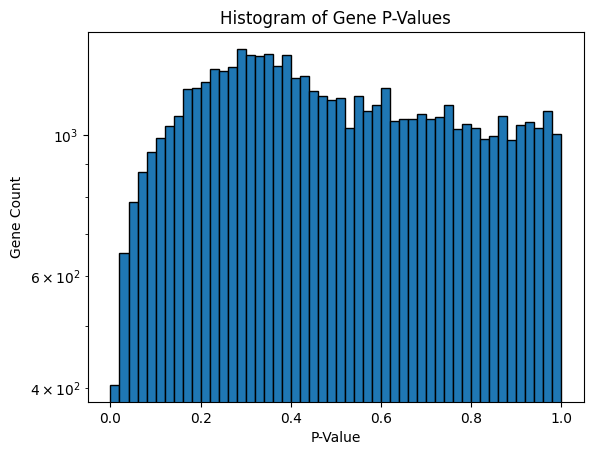

In [10]:
# Plotting a histogram of gene count vs. p-values to observe the overall distribution
sorted_p = p_values_series.sort_values()

plt.figure()
plt.hist(p_values_series, bins=50, edgecolor='k')
plt.yscale('log')
plt.xlabel('P-Value')
plt.ylabel('Gene Count')
plt.title('Histogram of Gene P-Values')
plt.show()

In [11]:
significant_genes = p_values_series[p_values_series < 0.01].sort_values()
top_genes = significant_genes.index.tolist()

df_filtered = df_transposed[top_genes + ['Label']]
df_filtered

ID_REF,1564974_at,204362_at,222200_s_at,217717_s_at,202557_at,225857_s_at,218671_s_at,203152_at,208937_s_at,204857_at,...,218351_at,211729_x_at,232595_at,219675_s_at,1557724_a_at,209568_s_at,243676_at,227119_at,229758_at,Label
GSM4654222,7.123250,10241.40,779.3430,1596.170,1748.7500,566.228,2214.300,640.236,13.93400,145.85000,...,1299.000,1437.760,21.884700,3173.9700,44.31040,2876.740,3.79874,5851.730,141.1130,Healthy
GSM4654223,20.704900,15129.10,891.6490,864.002,2549.0300,576.998,1838.320,1712.300,7.80593,154.40500,...,3201.570,2071.460,6.241090,76.2291,3.02636,908.610,35.19370,5459.670,159.6990,Healthy
GSM4654224,17.967200,8346.15,730.2020,3022.880,3309.0800,645.497,1811.030,1782.590,4.56626,188.92600,...,3479.880,4180.890,6.842210,1849.2300,1.23459,3567.530,5.99038,5130.580,189.8280,Healthy
GSM4654225,17.836200,9077.29,692.9420,2503.540,2968.0700,621.609,3305.870,2542.760,2.40576,77.44890,...,1437.410,7781.250,11.162900,943.9250,11.97520,1354.260,7.17486,9695.270,351.7130,Healthy
GSM4654226,15.639900,9443.00,516.9860,1060.370,752.1510,1076.190,2153.350,1367.430,4.72360,25.17980,...,1917.010,1845.970,2.838420,1233.5000,3.03324,1287.180,2.76109,7475.090,125.1310,Healthy
GSM4654227,11.544900,8426.38,693.7450,3210.980,2149.7800,398.780,2136.060,1118.090,7.28731,59.04560,...,2990.320,4245.190,0.696452,2235.8100,15.56910,4999.740,20.21550,3200.240,36.4395,Healthy
GSM4654228,4.292440,3890.96,389.9980,1569.650,2253.8300,1106.840,1240.400,1137.360,8.22589,25.04840,...,1627.130,3201.890,10.881300,311.5280,36.31540,2457.770,8.23003,4112.440,84.0614,Cancer
GSM4654229,4.345410,3916.77,388.7310,1154.580,845.7220,663.760,1670.430,364.234,24.62950,3.61850,...,362.470,1137.230,10.352700,392.1740,68.75040,1825.490,14.26250,6162.180,20.6166,Cancer
GSM4654230,2.023250,4843.09,393.5750,1504.360,633.1790,1014.190,1874.320,841.377,20.27090,39.35240,...,1884.590,2164.220,13.187300,449.8760,8.18341,1970.660,3.95728,6292.930,54.3116,Cancer
GSM4654231,2.620750,6286.12,250.2130,800.354,1192.6000,1138.630,390.933,142.056,28.87960,10.28120,...,1235.430,539.066,17.109400,137.9030,31.99570,249.553,2.69408,2334.270,36.9853,Cancer


### Dimensionality Reduction

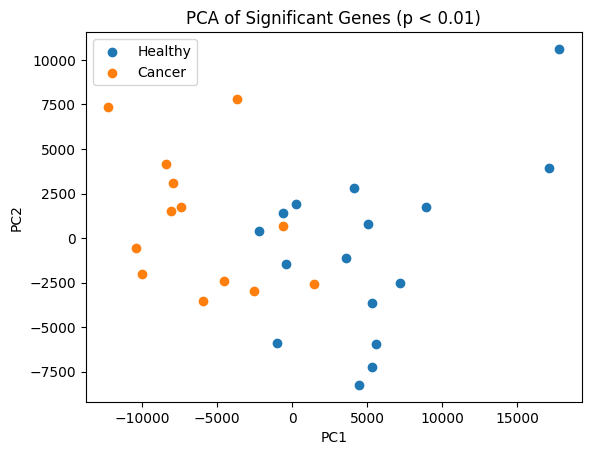

In [23]:
# Reducing dimensions using PCA for plotting
from sklearn.decomposition import PCA

X = df_filtered.drop('Label', axis=1).astype(float)
y = df_filtered['Label']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
for label in y.unique():
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=label)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA of Significant Genes (p < 0.01)')
plt.show()

### Significant Genes

The following 156 gene probes showed strong differences in expression between breast cancer and healthy patients, indicating their potential as cancer biomarkers.

In [24]:
# Ensuring that all rows are displayed
pd.set_option('display.max_rows', None)

# Reading the Platform table that has details of each probe
platform = pd.read_csv('GPL570-55999.txt', sep='\t', comment='#', low_memory=False)

# Converting the list of top genes selected above into
# a DataFrame for merging with the Platform table
top_genes_df = pd.DataFrame(top_genes, columns=['ID'])

# Selecting the columns to display from the Platform table
probe_to_gene = platform[['ID', 'Gene Symbol', 'Gene Title']]

# Merge the top genes table with the Platform table based on Probe ID
gene_info = top_genes_df.merge(probe_to_gene, on='ID', how='left')
gene_info = gene_info.rename(columns={'ID':'Probe ID'})
gene_info

,Probe ID,Gene Symbol,Gene Title
0,1564974_at,KRTAP8-1,keratin associated protein 8-1
1,204362_at,SKAP2,src kinase associated phosphoprotein 2
2,222200_s_at,BSDC1,BSD domain containing 1
3,217717_s_at,YWHAB,tyrosine 3-monooxygenase/tryptophan 5-monooxyg...
4,202557_at,HSPA13,"heat shock protein 70kDa family, member 13"
5,225857_s_at,SNHG17,small nucleolar RNA host gene 17 (non-protein ...
6,218671_s_at,ATPIF1,ATPase inhibitory factor 1
7,203152_at,MRPL40,mitochondrial ribosomal protein L40
8,208937_s_at,ID1,"inhibitor of DNA binding 1, dominant negative ..."
9,204857_at,MAD1L1,MAD1 mitotic arrest deficient-like 1 (yeast)
